# CryptoStatArb — Research Notebook

**Statistical Arbitrage in Cryptocurrencies** (WSQ Course Project)

Goal: research profitable **momentum and/or reversal** strategies on crypto,
backtest unconstrained, apply realistic execution costs (Binance.US, Tier 1),
and evaluate returns / vol / Sharpe / max drawdown / alpha-beta.

Exchange: [Binance.US](https://www.binance.us/fees)

In [1]:
# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Canonical dataset — build once via download_data.ipynb, then load here:
DATA_DIR = Path('data')
# panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
# close, volume = panel['Close'], panel['Volume']
# ret = close.pct_change()

In [2]:
# --- Binance.US commission (published standard rates, checked 2026-08-27) ---
FEES = {
    'maker_bps': 0.0,      # 0.00%  limit orders that ADD liquidity
    'taker_bps': 2.0,      # 0.02%  market orders that TAKE liquidity
    'bnb_discount': 0.05,  # 5% off maker & taker when fees paid in BNB
}

# Course-project baseline (from ClassProject brief) for cross-checking backtests:
#   market order = 7 bps commission + 13 bps assumed slippage = 20 bps all-in
#   limit order  = 7 bps commission only
PROJECT_COST_ASSUMPTION = {
    'commission_bps': 7.0,
    'slippage_bps': 13.0,
    'market_all_in_bps': 20.0,
    'limit_bps': 7.0,
}

# Asset-dependent costs (half-spread, impact) are filled in per symbol later, e.g.:
#   SYMBOL_TCOSTS = {'BTCUSDT': {'half_spread_bps': ..., 'impact_bps': ...}, ...}
SYMBOL_TCOSTS = {}

def bps(x):
    """basis points -> decimal (e.g. 20 -> 0.0020)."""
    return x / 1e4

FEES

{'maker_bps': 0.0, 'taker_bps': 2.0, 'bnb_discount': 0.05}

## Performance & Risk Metrics (reusable helpers)

Conventions match the WSQ lectures. Inputs:
- `strat_ret` — per-bar strategy **return** Series.
- `port` — the **weights** DataFrame (time × asset) used for turnover.
- `benchmark` — a market return Series (e.g. equal-weight universe) for beta.
- `ann` — periods per year for annualization: hourly `24*365`; b-hour `24*365/b`.

In [3]:
# --- Performance & risk metrics ---------------------------------------------
ANN_HOURLY = 24 * 365   # bars per year for hourly data (crypto trades 24/7)

def sharpe(ret, ann=ANN_HOURLY):
    """Annualized Sharpe ratio of a per-period return series."""
    return ret.mean() / ret.std() * np.sqrt(ann)

def drawdown(equity):
    """Drawdown series from an equity/price curve (WSQ convention)."""
    return equity / equity.expanding(min_periods=1).max() - 1

def equity_curve(ret):
    """Compounded equity from per-period returns (starts at 1)."""
    return (1 + ret.fillna(0)).cumprod()

def max_drawdown(ret):
    """Worst peak-to-trough drawdown (a negative number)."""
    return drawdown(equity_curve(ret)).min()

def max_dd_duration(ret):
    """Longest underwater stretch in BARS (peak until a new high is made)."""
    eq = equity_curve(ret)
    underwater = eq < eq.expanding(min_periods=1).max()
    return int(underwater.groupby((~underwater).cumsum()).cumsum().max())

def turnover(port):
    """Per-period turnover: sum_i |w_it - w_i,t-1|  (WSQ formula). Returns a Series."""
    return (port.fillna(0) - port.shift().fillna(0)).abs().sum(1)

def beta(strat_ret, benchmark_ret):
    """Market beta = OLS slope of strategy returns on a benchmark return series."""
    d = pd.concat([strat_ret, benchmark_ret], axis=1).dropna()
    X = sm.add_constant(d.iloc[:, 1])
    return sm.OLS(d.iloc[:, 0], X).fit().params.iloc[1]

def beta_contribution(strat_ret, benchmark_ret):
    """The beta * benchmark component of returns (the 'market' part of P&L)."""
    return beta(strat_ret, benchmark_ret) * benchmark_ret

def performance_summary(strat_ret, port=None, benchmark=None, ann=ANN_HOURLY, name='strategy'):
    """One-row summary of all key metrics for a strategy return series."""
    s = {
        'ann_return':      strat_ret.mean() * ann,
        'ann_vol':         strat_ret.std() * np.sqrt(ann),
        'sharpe':          sharpe(strat_ret, ann),
        'avg_turnover':    turnover(port).mean() if port is not None else np.nan,
        'max_drawdown':    max_drawdown(strat_ret),
        'max_dd_dur_bars': max_dd_duration(strat_ret),
        'beta':            beta(strat_ret, benchmark) if benchmark is not None else np.nan,
    }
    return pd.Series(s, name=name)

def summary_table(strats, ports=None, benchmark=None, ann=ANN_HOURLY):
    """Metrics table (rows = strategies) from a dict {name: return_series}.
       `ports`: optional {name: weights_df};  `ann`: scalar or {name: ann}."""
    rows = []
    for nm, r in strats.items():
        p = ports.get(nm) if isinstance(ports, dict) else None
        a = ann.get(nm, ANN_HOURLY) if isinstance(ann, dict) else ann
        rows.append(performance_summary(r, p, benchmark, a, nm))
    return pd.DataFrame(rows)

print('metrics ready:', [f.__name__ for f in
      (sharpe, drawdown, max_drawdown, max_dd_duration, turnover, beta, performance_summary, summary_table)])

metrics ready: ['sharpe', 'drawdown', 'max_drawdown', 'max_dd_duration', 'turnover', 'beta', 'performance_summary', 'summary_table']


### Using the metrics

```python
mkt = ret.mean(axis=1)                       # equal-weight 'market' benchmark

# one strategy:
performance_summary(strat_ret, port, benchmark=mkt, ann=24*365)

# several at once (e.g. per holding interval) -> a table:
summary_table({'1h': r1, '2h': r2},
              ports={'1h': p1, '2h': p2},
              benchmark=mkt,
              ann={'1h': 24*365, '2h': 24*365/2})
```
For a b-hour strategy set `ann = 24*365/b`. `max_dd_dur_bars` is in bars — multiply by the
bar length for wall-clock time.

## Data & Log Prices

Load the canonical panel (built by `download_data.ipynb`), resample to **daily** closes, and take **log prices** (then log returns) — the base series for the reversal research below. A chronological **80/20 train/test split** (defined at the end) is set aside for out-of-sample validation of any signal.

In [4]:
# --- Daily log prices for all coins (resample hourly UTC close -> daily close) ---
# Daily (not hourly) so the ADF test isn't drowned in 40k obs of excess power.
close = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close']
dclose = close.resample('1D').last()
logpx = np.log(dclose)
print('daily log-price panel:', logpx.shape, '|', logpx.index.min().date(), '->', logpx.index.max().date())
logpx.tail()

daily log-price panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,-2.3925,4.8808,-1.5079,-2.3919,-1.9235,-1.4524,0.4200,-4.3306,2.0200,-0.0182,...,-1.4740,1.4490,-5.1678,-5.6840,-7.8833,-1.6439,7.8528,6.7202,1.6956,-2.3157
2026-08-25 00:00:00+00:00,-2.3570,4.8347,-1.5649,-2.4137,-1.9604,-1.4524,0.4167,-4.3709,1.9912,0.0583,...,-1.6296,1.4351,-5.1795,-5.6840,-7.9074,-1.7019,7.8528,6.6436,1.6292,-2.3486
2026-08-26 00:00:00+00:00,-2.3623,4.8363,-1.5481,-2.4088,-1.9733,-1.4524,0.4095,-4.3725,2.0081,-0.0471,...,-1.5995,1.4791,-5.0046,-5.6840,-7.8240,-1.6870,7.6563,6.7049,1.6094,-2.3026
2026-08-27 00:00:00+00:00,-2.3570,4.8577,-1.5421,-2.3928,-1.9442,-1.4524,0.4511,-4.3103,2.0189,-0.0141,...,-1.5945,1.5510,-4.9362,-5.6840,-7.7848,-1.6738,7.6563,6.6967,1.6974,-2.3056
2026-08-28 00:00:00+00:00,-2.4453,4.8112,-1.5941,-2.4421,-1.9885,-1.4439,0.3743,-4.2708,1.9844,-0.0141,...,-1.6503,1.4893,-5.0056,-5.6840,-7.8291,-1.7217,7.6563,6.6727,1.5933,-2.3549


## Exploratory Data Analysis

Understand the universe before any strategy work:
1. **Log returns** — `logret = logpx.diff()`, daily continuously-compounded returns.
2. **Price history** — raw daily close for all 60 coins (small multiples).
3. **Return correlation** — Pearson correlation of daily log returns, on a heatmap.
4. **Intraday structure (GAM)** — seasonality of returns / volume / volatility over hour-of-day × weekday, and the hour-on-hour return-**predictability** map (momentum vs reversal).

The 80/20 split at the very end is **set aside** for later signal modeling — none of the EDA uses it.

In [5]:
# --- Daily log returns for all coins:  r_t = log(P_t) - log(P_{t-1}) ---
logret = logpx.diff()
print('daily log-return panel:', logret.shape, '|',
      logret.index.min().date(), '->', logret.index.max().date())
logret.tail()

daily log-return panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,0.0379,-0.0696,-0.0260,-0.0297,-0.0210,0.0662,-0.0562,0.0411,-0.0098,0.0696,...,-0.0216,-0.0584,-0.0162,0.0606,0.0107,-0.0329,0.0746,-0.0284,0.0450,-0.0446
2026-08-25 00:00:00+00:00,0.0355,-0.0461,-0.0570,-0.0219,-0.0370,0.0000,-0.0033,-0.0403,-0.0288,0.0764,...,-0.1556,-0.0139,-0.0117,0.0000,-0.0242,-0.0580,0.0000,-0.0766,-0.0664,-0.0330
2026-08-26 00:00:00+00:00,-0.0053,0.0016,0.0168,0.0049,-0.0129,0.0000,-0.0073,-0.0016,0.0169,-0.1054,...,0.0302,0.0440,0.1749,0.0000,0.0834,0.0149,-0.1965,0.0612,-0.0198,0.0460
2026-08-27 00:00:00+00:00,0.0053,0.0214,0.0060,0.0160,0.0291,0.0000,0.0416,0.0622,0.0108,0.0330,...,0.0049,0.0719,0.0684,0.0000,0.0392,0.0132,0.0000,-0.0081,0.0880,-0.0030
2026-08-28 00:00:00+00:00,-0.0883,-0.0465,-0.0520,-0.0492,-0.0443,0.0085,-0.0768,0.0394,-0.0345,0.0000,...,-0.0557,-0.0617,-0.0695,0.0000,-0.0442,-0.0478,0.0000,-0.0240,-0.1041,-0.0493


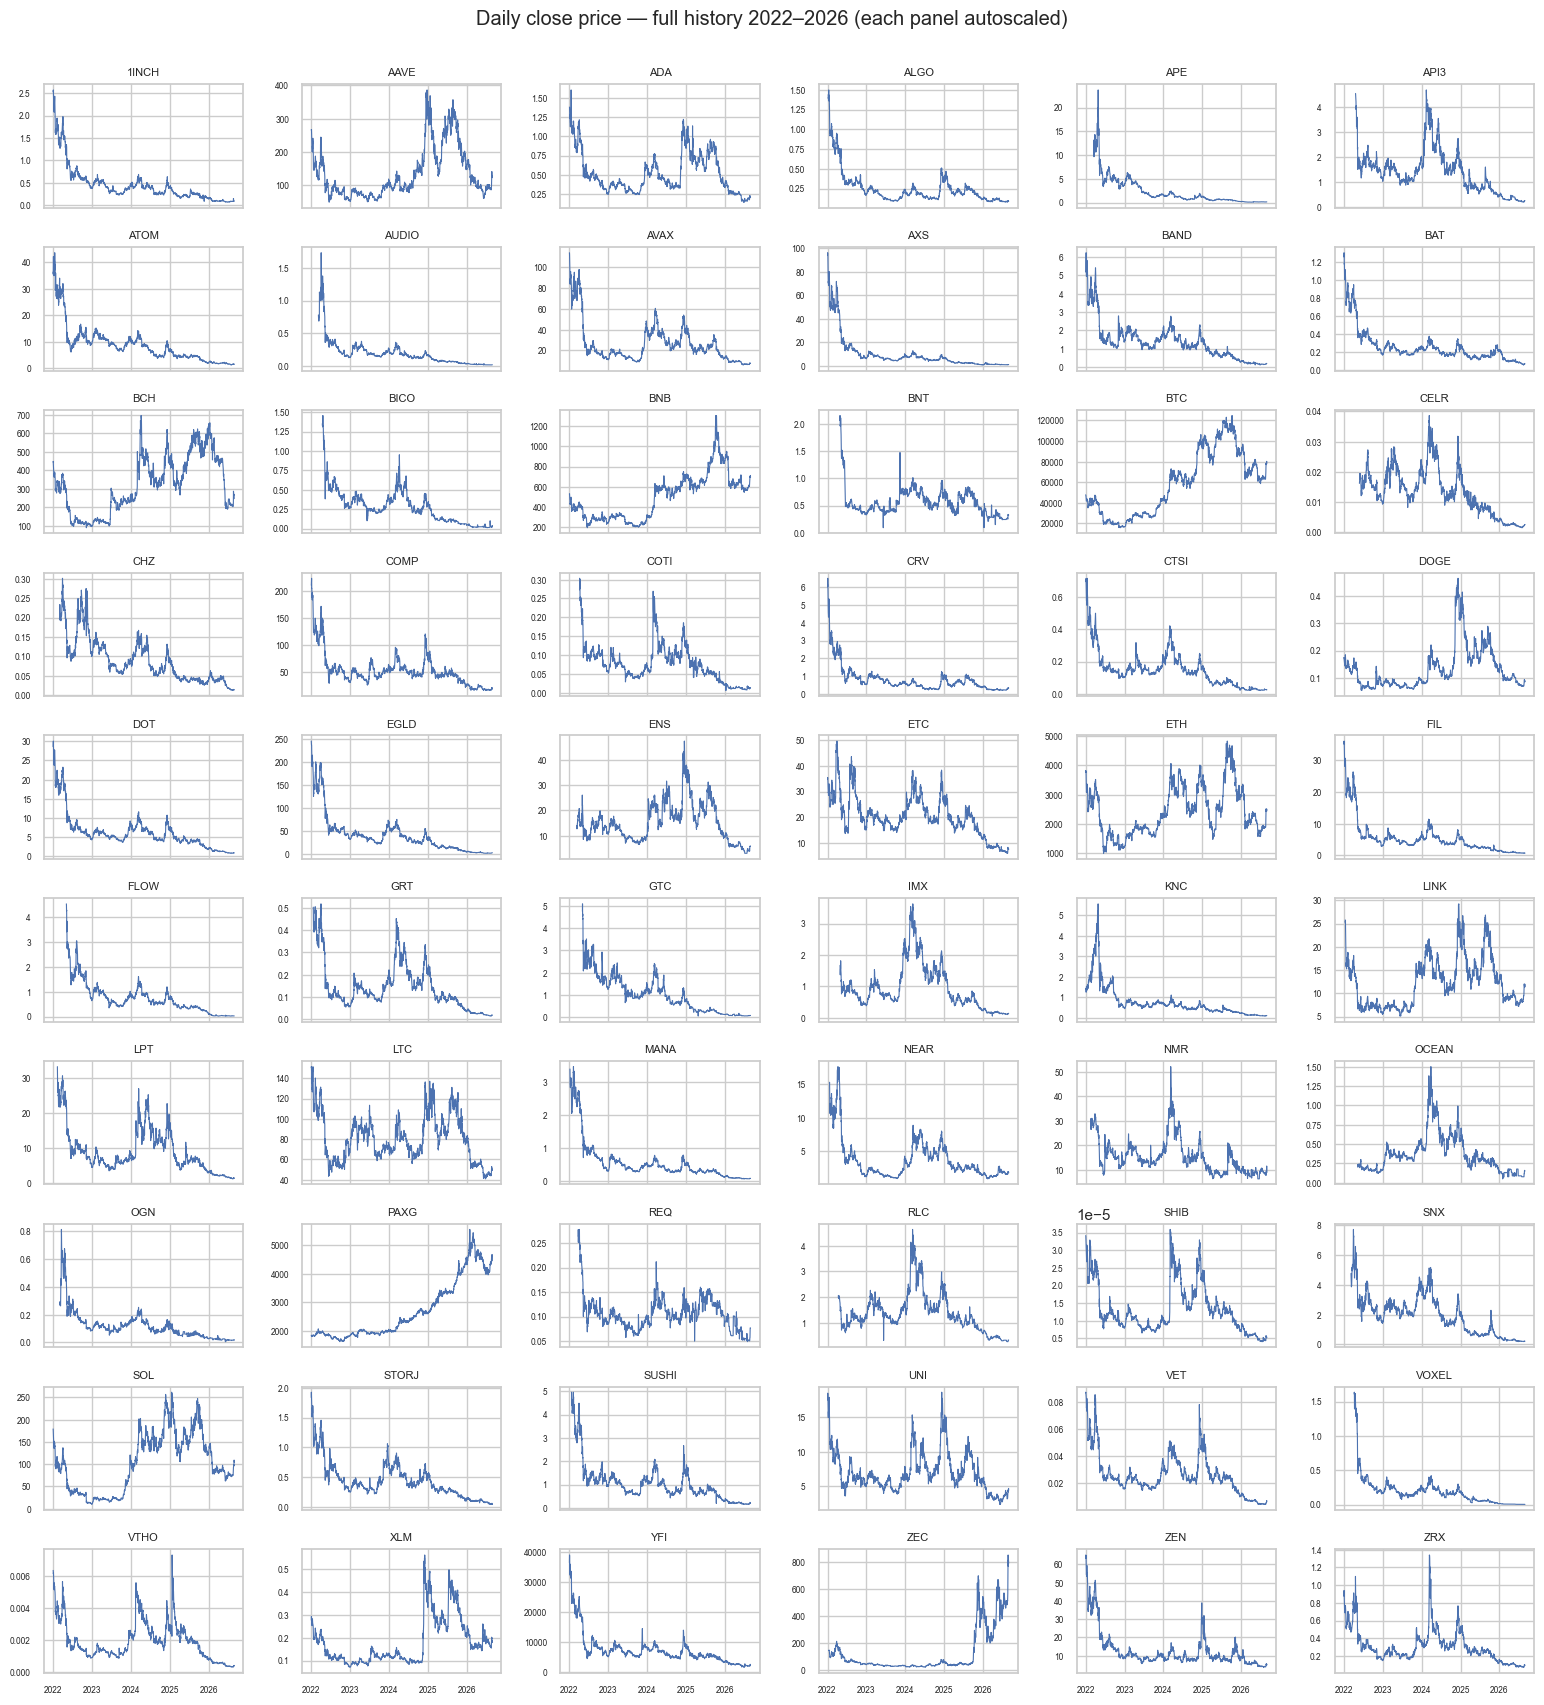

In [6]:
# --- Raw daily close price, full history, one panel per coin ---
# Own y-axis per panel: prices span BTC ~1e5 down to SHIB ~1e-5, so a shared axis is useless.
cols = list(dclose.columns)
ncol = 6
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.6, nrow * 1.7), sharex=True)
for ax, c in zip(axes.flat, cols):
    ax.plot(dclose.index, dclose[c], lw=0.8)
    ax.set_title(c.replace('USDT', ''), fontsize=8)
    ax.tick_params(labelsize=6)
for ax in axes.flat[len(cols):]:
    ax.axis('off')
fig.suptitle('Daily close price — full history 2022–2026 (each panel autoscaled)', y=1.002)
fig.tight_layout()
plt.show()

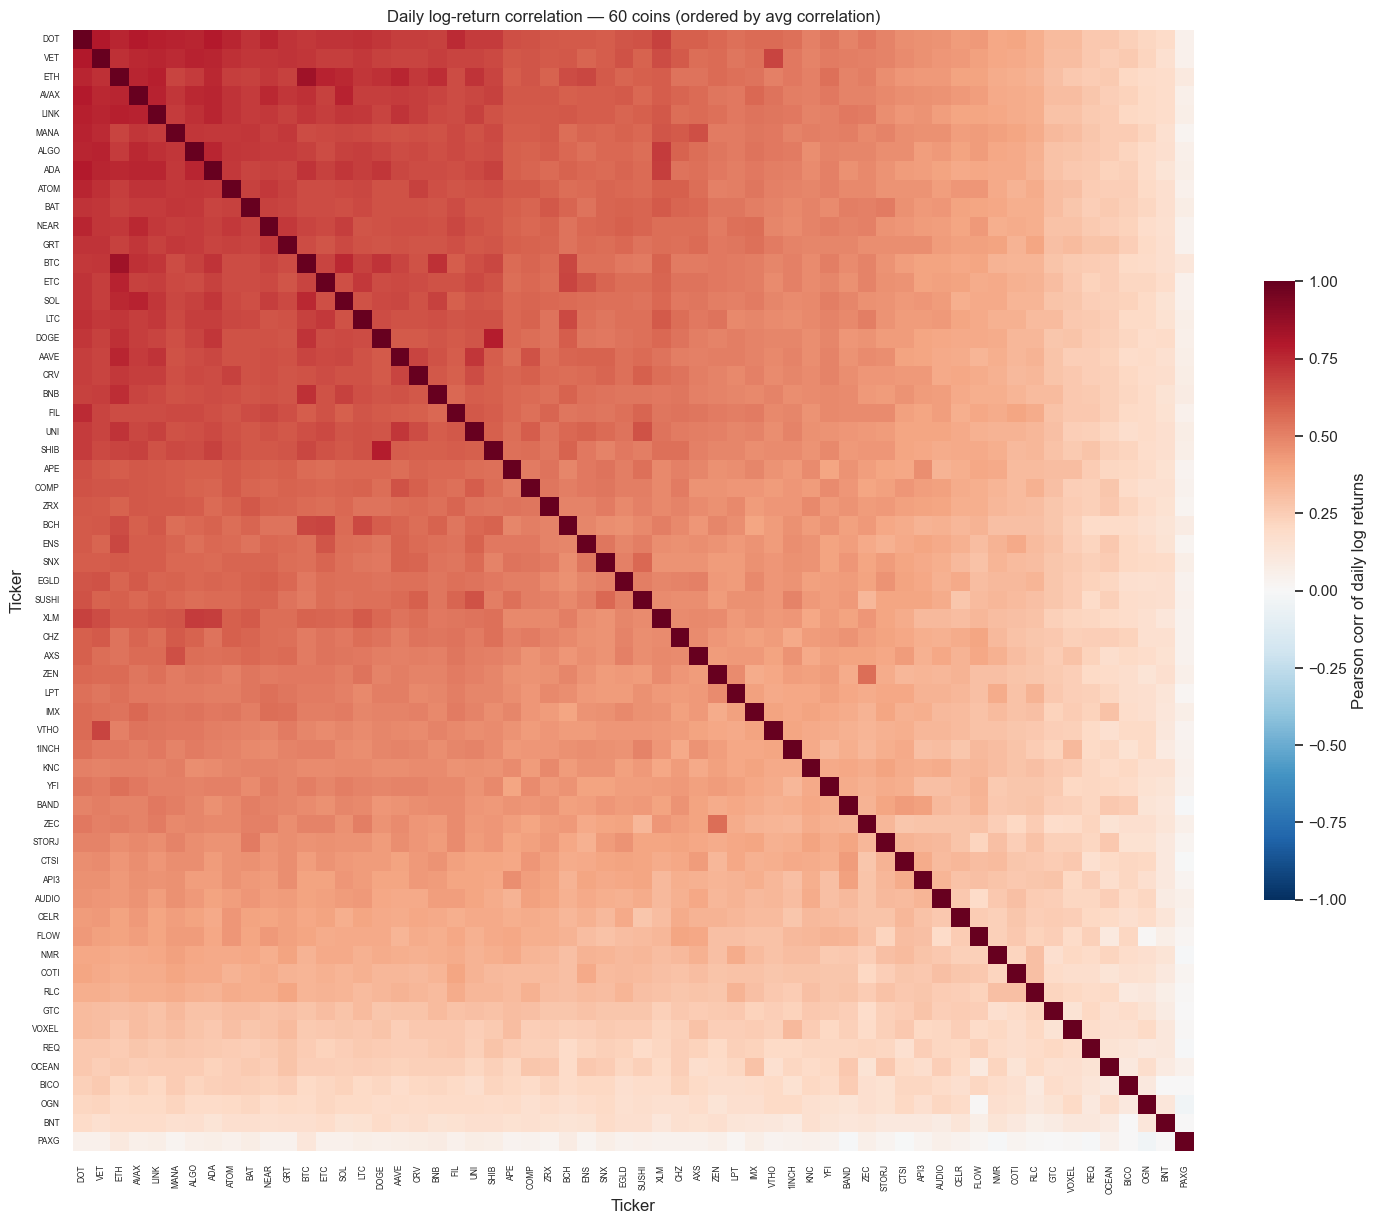

mean pairwise corr = 0.421 | min = -0.035 | max = 0.846


In [7]:
# --- Correlation matrix of daily log returns across all 60 coins ---
corr = logret.corr()
# order by average correlation so the tightly-coupled majors cluster into a visible block
order = corr.mean().sort_values(ascending=False).index
corr = corr.loc[order, order]
labels = [c.replace('USDT', '') for c in corr.columns]

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Pearson corr of daily log returns', 'shrink': 0.5}, ax=ax)
ax.set_title('Daily log-return correlation — 60 coins (ordered by avg correlation)')
ax.tick_params(labelsize=6)
fig.tight_layout()
plt.show()

offdiag = corr.values[np.triu_indices_from(corr, k=1)]
print(f'mean pairwise corr = {offdiag.mean():.3f} | min = {offdiag.min():.3f} | max = {offdiag.max():.3f}')

## Intraday seasonality via GAM (Härdle et al., "Rise of the Machines")

Reproducing the paper's intraday high-frequency visuals on our **hourly** data (theirs was 5-min),
for the majors **BTC, ETH, XRP, SOL, LTC**. A Generalized Additive Model smooths a noisy quantity
against a *time coordinate*:

- **Absolute returns** vs hour-of-day and vs weekday — 1D cubic-spline smooths with CI bands (paper Figs 7–8).
- **Trading volume** as a 2D **surface** over (hour-of-day × weekday) — tensor-product smooth (paper Fig 9).
- **Volatility** (Parkinson high–low range) as the same 2D surface (paper Fig 10).

The paper's thesis: if trading were purely algorithmic/24-7, these surfaces would be flat. The humps
at working hours / weekdays are the "proof of human." Times here are **UTC** (the paper used +1 GMT).
Requires `pygam` (`pip install pygam`); **XRP** is loaded from a side file since it's not in the main panel.

{'BTC': 40811, 'ETH': 40811, 'XRP': 27392, 'SOL': 40811, 'LTC': 40811} hourly rows per coin


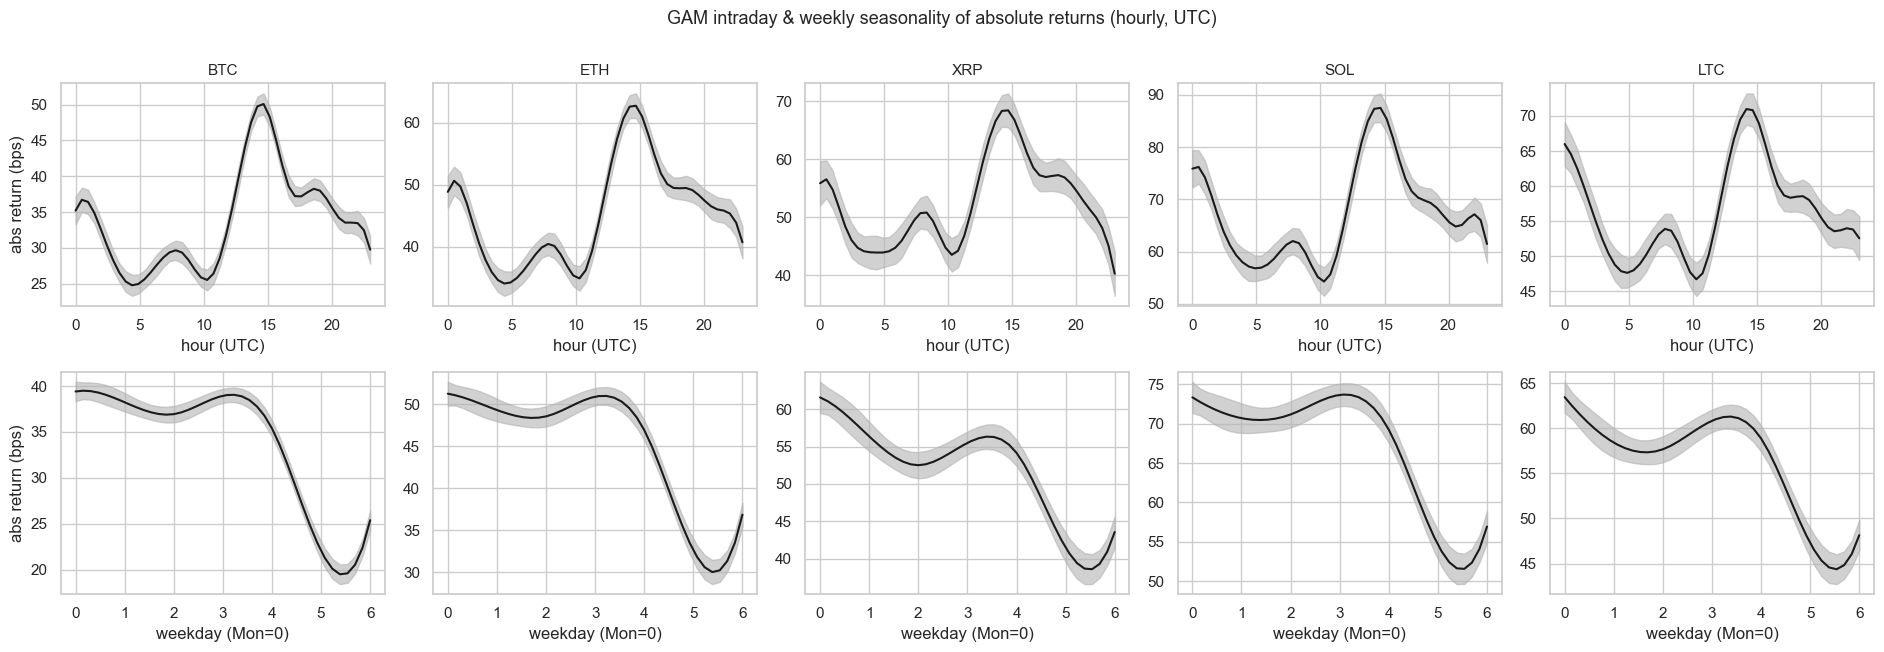

In [8]:
# --- GAM setup: per-coin hourly frame (returns / Parkinson vol / volume, hour, weekday) ---
import warnings; warnings.filterwarnings('ignore')
from pygam import LinearGAM, s, te
from matplotlib import cm

panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
GAM_COINS = ['BTC', 'ETH', 'XRP', 'SOL', 'LTC']

def coin_frame(tk):
    """Hourly OHLCV -> abs return, Parkinson range-vol, volume, plus hour & weekday coords."""
    d = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk') if tk == 'XRP'
         else panel.xs(tk + 'USDT', axis=1, level='Ticker')[['Open','High','Low','Close','Volume']])
    d = d.dropna(subset=['Close'])
    f = pd.DataFrame(index=d.index)
    f['abs_ret'] = np.log(d.Close).diff().abs()
    f['parkvol'] = np.sqrt((np.log(d.High / d.Low) ** 2) / (4 * np.log(2)))   # Parkinson HL vol
    f['volume']  = d.Volume
    f['hour']    = d.index.hour
    f['wday']    = d.index.dayofweek                                          # Mon=0 .. Sun=6
    return f.dropna()

gam_frames = {c: coin_frame(c) for c in GAM_COINS}
print({c: gam_frames[c].shape[0] for c in GAM_COINS}, 'hourly rows per coin')

# --- Fig 7/8: daily & weekly GAM seasonality of ABSOLUTE RETURNS (with CI bands) ---
fig, axes = plt.subplots(2, 5, figsize=(19, 6.5))
for j, c in enumerate(GAM_COINS):
    f = gam_frames[c]
    g = LinearGAM(s(0, n_splines=14)).fit(f[['hour']].values, f['abs_ret'].values * 1e4)
    xx = g.generate_X_grid(term=0, n=48); ci = g.confidence_intervals(xx)
    ax = axes[0, j]; ax.plot(xx[:, 0], g.predict(xx), 'k')
    ax.fill_between(xx[:, 0], ci[:, 0], ci[:, 1], color='0.7', alpha=.6)
    ax.set_title(c, fontsize=11); ax.set_xlabel('hour (UTC)')
    if j == 0: ax.set_ylabel('abs return (bps)')
    g2 = LinearGAM(s(0, n_splines=6)).fit(f[['wday']].values, f['abs_ret'].values * 1e4)
    xw = g2.generate_X_grid(term=0, n=40); cw = g2.confidence_intervals(xw)
    ax = axes[1, j]; ax.plot(xw[:, 0], g2.predict(xw), 'k')
    ax.fill_between(xw[:, 0], cw[:, 0], cw[:, 1], color='0.7', alpha=.6)
    ax.set_xlabel('weekday (Mon=0)'); ax.set_xticks(range(7))
    if j == 0: ax.set_ylabel('abs return (bps)')
fig.suptitle('GAM intraday & weekly seasonality of absolute returns (hourly, UTC)', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

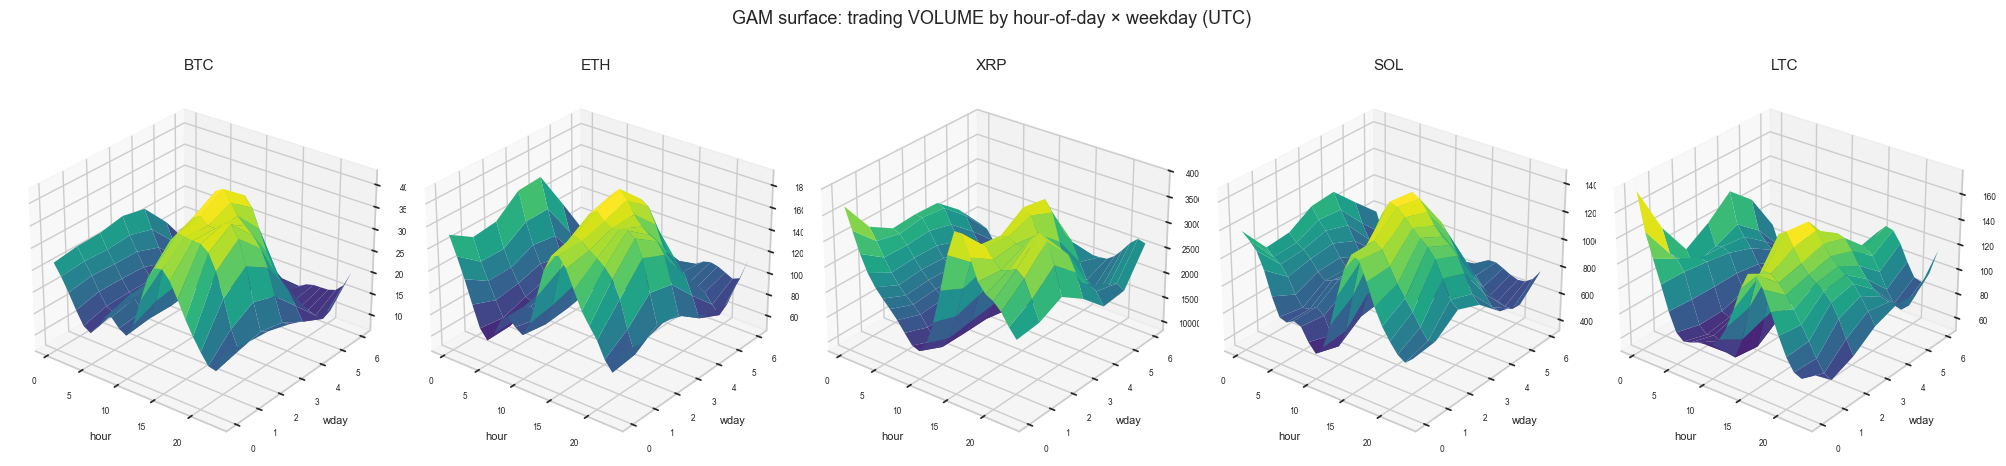

In [9]:
# --- Fig 9: trading VOLUME as a GAM surface over (hour-of-day x weekday) ---
Hgrid, Wgrid = np.meshgrid(np.linspace(0, 23, 24), np.linspace(0, 6, 7))

def gam_surface(field, scale, title):
    fig = plt.figure(figsize=(20, 4.6))
    for j, c in enumerate(GAM_COINS):
        f = gam_frames[c]
        g = LinearGAM(te(0, 1, n_splines=[12, 6])).fit(f[['hour', 'wday']].values, f[field].values * scale)
        Z = g.predict(np.c_[Hgrid.ravel(), Wgrid.ravel()]).reshape(Hgrid.shape)
        ax = fig.add_subplot(1, 5, j + 1, projection='3d')
        ax.plot_surface(Hgrid, Wgrid, Z, cmap=cm.viridis, antialiased=True, linewidth=0)
        ax.set_title(c, fontsize=11); ax.set_xlabel('hour', fontsize=8); ax.set_ylabel('wday', fontsize=8)
        ax.tick_params(labelsize=6); ax.view_init(elev=28, azim=-52)
    fig.suptitle(title, y=1.02, fontsize=13); fig.tight_layout(); plt.show()

gam_surface('volume', 1.0, 'GAM surface: trading VOLUME by hour-of-day × weekday (UTC)')

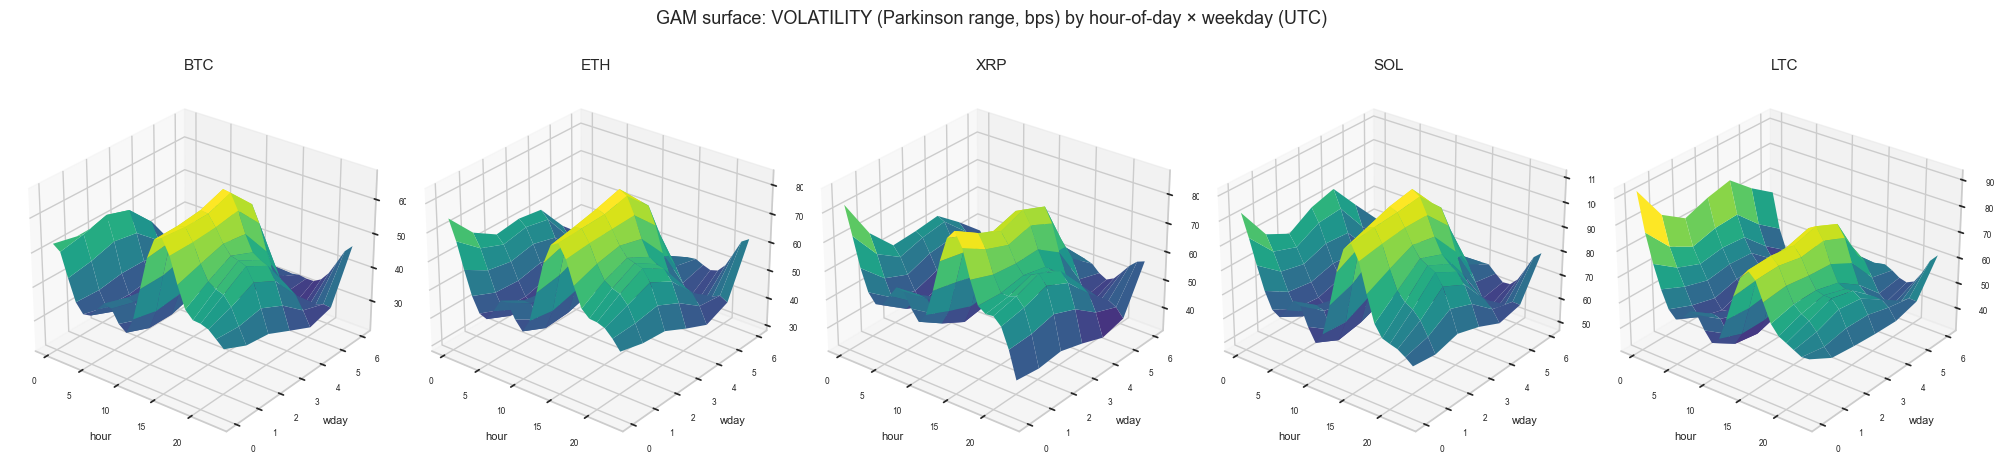

In [10]:
# --- Fig 10: VOLATILITY (Parkinson range) as a GAM surface over (hour-of-day x weekday) ---
gam_surface('parkvol', 1e4, 'GAM surface: VOLATILITY (Parkinson range, bps) by hour-of-day × weekday (UTC)')

## Intraday return predictability: momentum & reversal (Wen et al.)

Following Wen, Bouri, Xu & Zhao (SSRN 4135239): does an **earlier hour's return predict a later
hour's return** within the same UTC day? For every ordered pair of hours `(j → k)` with `j < k`, we
regress `r_k = a + b·r_j` across days. The slope's sign and t-stat (identical to `corr(r_j, r_k)`'s)
tell us the character of the lead-lag:

- **t > 0 → momentum** (continuation): a move in hour *j* tends to continue into hour *k*.
- **t < 0 → reversal**: a move in hour *j* tends to reverse by hour *k*.

The paper's headline — and the reason this matters for us — is that crypto shows **both**, unlike
equities (momentum only). A heatmap of t-stats over (predictor hour × target hour) maps *when*
intraday momentum vs reversal lives, for BTC/ETH/XRP/SOL/LTC. (Caveat: 276 pairs/coin ⇒ ~14 false
positives each at 5%, so trust cells that are **consistent across coins**, not one-offs.)

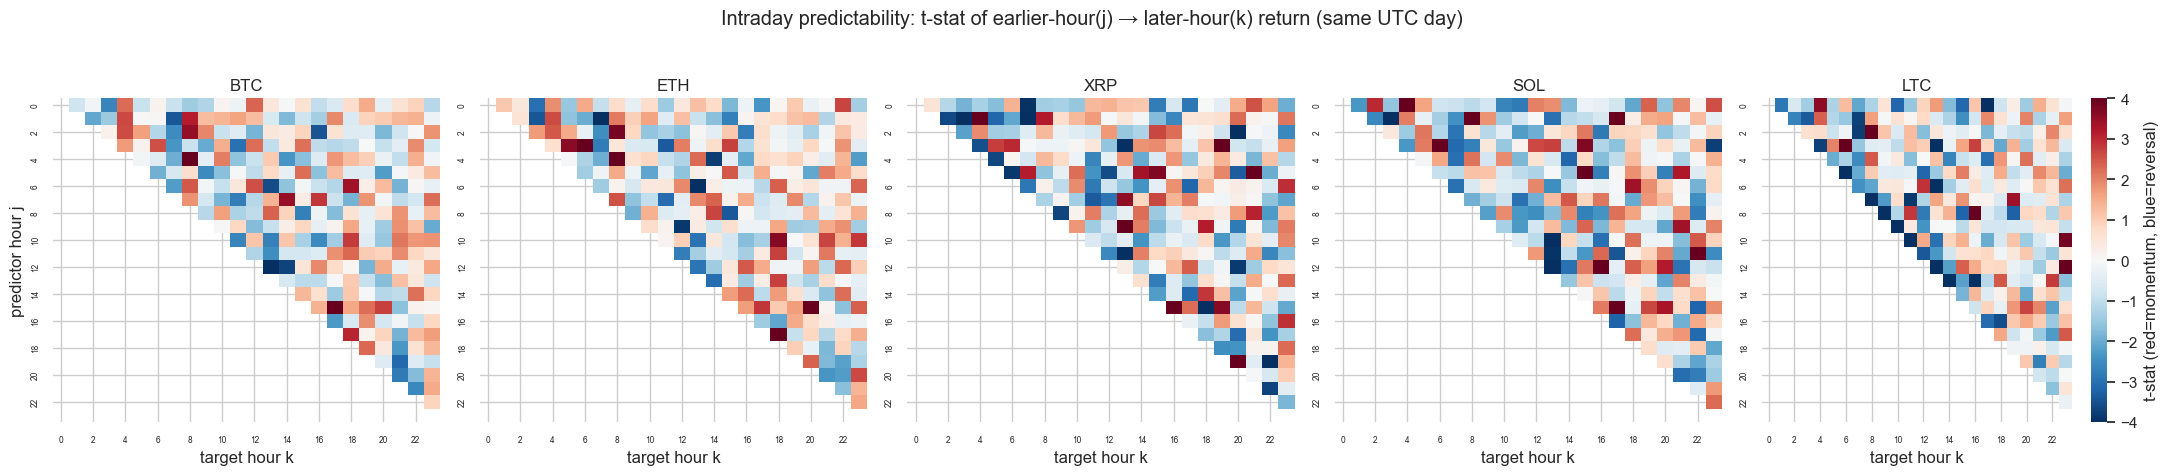

coin   pairs  sig_mom  sig_rev   (|t| > 1.96)
BTC      276       28       27
ETH      276       34       28
XRP      276       37       50
SOL      276       41       51
LTC      276       24       49

Most consistent MOMENTUM lead-lags j→k (avg t across 5 coins):
pred_h  tgt_h
3       6       3.8600
15      17      3.0700
5       15      3.0600
1       8       3.0500
4       8       2.9700
1       4       2.7400

Most consistent REVERSAL lead-lags j→k:
pred_h  tgt_h
1       7       -3.9600
12      13      -3.6200
1       3       -3.5500
11      13      -3.4700
7       11      -3.2100
6       13      -3.1900


In [11]:
# --- Intraday predictability: earlier-hour(j) -> later-hour(k) return, same UTC day ---
INTRADAY_COINS = ['BTC', 'ETH', 'XRP', 'SOL', 'LTC']

def hourly_logret(tk):
    c = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk')['Close'] if tk == 'XRP'
         else pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close'][tk + 'USDT'])
    return np.log(c).diff()

def day_hour_matrix(tk):
    """(day × 24) matrix of hourly log returns; columns = hour-of-day 0..23 (UTC)."""
    r = hourly_logret(tk).dropna()
    M = r.groupby([r.index.normalize(), r.index.hour]).first().unstack()
    M = M.reindex(columns=range(24)); M.columns.name = 'tgt_h'; M.index.name = 'day'
    return M

def intraday_tgrid(tk):
    """t-stat of slope in r_k = a + b·r_j for every earlier hour j < later hour k (== t of corr)."""
    M = day_hour_matrix(tk); n = len(M); C = M.corr()
    with np.errstate(invalid='ignore', divide='ignore'):
        T = C * np.sqrt((n - 2) / (1 - C ** 2))
    T = T.where(np.triu(np.ones_like(T, dtype=bool), k=1))    # predictor(row j) < target(col k)
    T.index.name = 'pred_h'; T.columns.name = 'tgt_h'
    return T

tgrids = {c: intraday_tgrid(c) for c in INTRADAY_COINS}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
for i, (ax, c) in enumerate(zip(axes, INTRADAY_COINS)):
    sns.heatmap(tgrids[c], cmap='RdBu_r', vmin=-4, vmax=4, center=0, ax=ax,
                cbar=(i == 4), cbar_kws={'label': 't-stat (red=momentum, blue=reversal)'})
    ax.set_title(c); ax.set_xlabel('target hour k'); ax.tick_params(labelsize=6)
    ax.set_ylabel('predictor hour j' if i == 0 else '')
fig.suptitle('Intraday predictability: t-stat of earlier-hour(j) → later-hour(k) return (same UTC day)', y=1.03)
fig.tight_layout(); plt.show()

# significant-cell counts + cross-coin consensus
print(f'{"coin":5}{"pairs":>7}{"sig_mom":>9}{"sig_rev":>9}   (|t| > 1.96)')
for c in INTRADAY_COINS:
    v = tgrids[c].stack().values
    print(f'{c:5}{v.size:>7}{int((v > 1.96).sum()):>9}{int((v < -1.96).sum()):>9}')

avg_t = pd.concat([tgrids[c].stack().rename(c) for c in INTRADAY_COINS], axis=1).mean(axis=1)
print('\nMost consistent MOMENTUM lead-lags j→k (avg t across 5 coins):')
print(avg_t.sort_values(ascending=False).head(6).round(2).to_string())
print('\nMost consistent REVERSAL lead-lags j→k:')
print(avg_t.sort_values().head(6).round(2).to_string())

## Directional lag-1 reversal (conditional means)

A simpler, more direct reversal test than cointegration. For each coin, attach the **lag-1** log
return and the **sign** (+1/-1) of both today's and yesterday's return (as in HW8). Then group
today's return by *yesterday's direction*:

```python
df.groupby('close_log_return_lag_1_dir').aggregate({'close_log_return': ['mean','count','sum']})
```

**Reading it:** if the mean return **after a down day** (dir = -1) exceeds the mean **after an up day**
(dir = +1), the coin *reverses* — down begets up, up begets down. We define
`rev_spread = mean(after-down) − mean(after-up)` (**positive ⇒ reversal**) and Welch-t-test whether
the two conditional means differ. This is the sign-conditional cousin of lag-1 autocorrelation, run
on **daily** bars where the bid-ask-bounce artifact is far weaker than in our old hourly scan.

In [12]:
# --- Directional lag-1 reversal: per-ticker conditional means ---
def ticker_frame(tk):
    """HW-style frame: current daily log return, its lag-1, and the +1/-1 direction of each."""
    df = pd.DataFrame({'close_log_return': logret[tk]})
    df['close_log_return_lag_1'] = df['close_log_return'].shift(1)
    for col in ['close_log_return', 'close_log_return_lag_1']:
        df[f'{col}_dir'] = df[col].map(lambda x: 1 if x > 0 else -1)
    return df.dropna()

# Every ticker's groupby table (return conditioned on the SIGN of the prior day's return):
rev_tables = {tk: ticker_frame(tk)
                    .groupby('close_log_return_lag_1_dir')
                    .aggregate({'close_log_return': ['mean', 'count', 'sum']})
              for tk in logret.columns}

# Examples (call rev_tables['SOLUSDT'] etc. for any ticker):
print('BTC — return grouped by prior-day direction:')
display(rev_tables['BTCUSDT'])
print('ETH:')
display(rev_tables['ETHUSDT'])

BTC — return grouped by prior-day direction:


close_log_return              
                                       mean count     sum
close_log_return_lag_1_dir                               
-1                                  -0.0002   858 -0.1699
 1                                   0.0008   841  0.6680

ETH:


close_log_return              
                                       mean count     sum
close_log_return_lag_1_dir                               
-1                                   0.0000   842  0.0341
 1                                  -0.0006   857 -0.4837

In [13]:
# --- Consolidate across all 60: does each coin revert?  mean(after-down) - mean(after-up) ---
from scipy import stats

rows = []
for tk in logret.columns:
    d = ticker_frame(tk)
    up = d.loc[d['close_log_return_lag_1_dir'] == 1,  'close_log_return']
    dn = d.loc[d['close_log_return_lag_1_dir'] == -1, 'close_log_return']
    t, p = stats.ttest_ind(dn, up, equal_var=False)   # H0: equal conditional means (Welch)
    rows.append({'ticker': tk[:-4],
                 'after_up_bps':   up.mean() * 1e4,
                 'after_down_bps': dn.mean() * 1e4,
                 'rev_spread_bps': (dn.mean() - up.mean()) * 1e4,   # >0 => reversal
                 'n_up': len(up), 'n_dn': len(dn), 't_stat': t, 'p': p})
rev_summary = pd.DataFrame(rows).set_index('ticker').sort_values('rev_spread_bps', ascending=False)

n_rev  = int((rev_summary.rev_spread_bps > 0).sum())
n_sig  = int((rev_summary.p < 0.05).sum())
n_both = int(((rev_summary.p < 0.05) & (rev_summary.rev_spread_bps > 0)).sum())
print(f'reversal (spread>0): {n_rev}/60 | significant p<0.05: {n_sig}/60 | '
      f'significant AND reversal: {n_both}/60')
print(f'mean reversal spread across universe: {rev_summary.rev_spread_bps.mean():.1f} bps\n')
display(rev_summary.round(2))

reversal (spread>0): 50/60 | significant p<0.05: 28/60 | significant AND reversal: 28/60
mean reversal spread across universe: 53.8 bps



,after_up_bps,after_down_bps,rev_spread_bps,n_up,n_dn,t_stat,p
ticker,,,,,,,
OGN,-132.3300,43.2000,175.5400,561,1077,3.0300,0.0000
AUDIO,-111.8500,57.6700,169.5200,788,844,4.9800,0.0000
OCEAN,-99.4700,63.0300,162.5000,634,934,3.5900,0.0000
CHZ,-87.6600,45.8400,133.5000,765,875,4.7100,0.0000
VOXEL,-116.4600,5.4200,121.8700,578,1024,2.8100,0.0100
BNT,-90.0700,29.0700,119.1400,544,1040,2.4500,0.0100
REQ,-78.7800,31.3700,110.1400,577,1040,3.1700,0.0000
CELR,-68.7200,34.3000,103.0100,700,853,2.7600,0.0100
1INCH,-72.2300,26.1100,98.3400,795,904,3.3700,0.0000


### Filters: balanced up/down + out-of-sample stability

Two screens before trusting the reversal:

1. **Balanced up/down frequency.** The strongest reversers above (OGN, BNT, REQ…) are down-skewed
   dying coins — their "reversal" is entangled with a persistent downtrend, not a real edge. Keep only
   coins whose up-day fraction is near 50/50 (`|up_frac − 0.5| < 0.03`). At a *daily* rebalance the
   bid-ask bounce is a minor worry, so this balance screen — not liquidity — is the main de-biaser.

2. **Out-of-sample stability.** Run the *same* conditional-mean aggregation on the first 80% and the
   last 20% separately and check the reversal spread is *reasonably similar* — same sign, correlated
   ranking. An edge that only exists in-sample is curve-fit noise.

In [14]:
# --- Filter 1: balanced up/down frequency (drop coins whose 'reversal' is really a downtrend) ---
# A dying microcap has far more down days than up; its asymmetry fakes a reversal signal.
# Keep only coins whose up-day fraction sits near 50/50.
BALANCE_BAND = 0.03   # within 3 percentage points of a balanced up/down split

up_frac   = pd.Series({tk: (ticker_frame(tk)['close_log_return_lag_1_dir'] == 1).mean()
                       for tk in logret.columns})
imbalance = (up_frac - 0.5).abs()
balanced_syms = imbalance.index[imbalance < BALANCE_BAND].tolist()

print(f'kept {len(balanced_syms)}/60 balanced coins (|up_frac - 0.5| < {BALANCE_BAND})')
print('kept    :', sorted(t[:-4] for t in balanced_syms))
print('dropped (most down-skewed):',
      [t[:-4] for t in imbalance.sort_values().tail(10).index[::-1]])

kept 32/60 balanced coins (|up_frac - 0.5| < 0.03)
kept    : ['AAVE', 'ADA', 'ALGO', 'APE', 'ATOM', 'AUDIO', 'AVAX', 'BAT', 'BCH', 'BNB', 'BTC', 'COMP', 'CRV', 'DOGE', 'DOT', 'ETC', 'ETH', 'FIL', 'GRT', 'LINK', 'LTC', 'MANA', 'NEAR', 'PAXG', 'SHIB', 'SOL', 'SUSHI', 'UNI', 'VET', 'XLM', 'ZEC', 'ZRX']
dropped (most down-skewed): ['BICO', 'OGN', 'BNT', 'GTC', 'REQ', 'VOXEL', 'FLOW', 'RLC', 'API3', 'OCEAN']


train 2022-01-01 -> 2025-09-21 | test 2025-09-22 -> 2026-08-28
sign-match (same direction both halves): 19/32
cross-coin corr(train, test): 0.53
reversal-positive in BOTH halves: 13/32



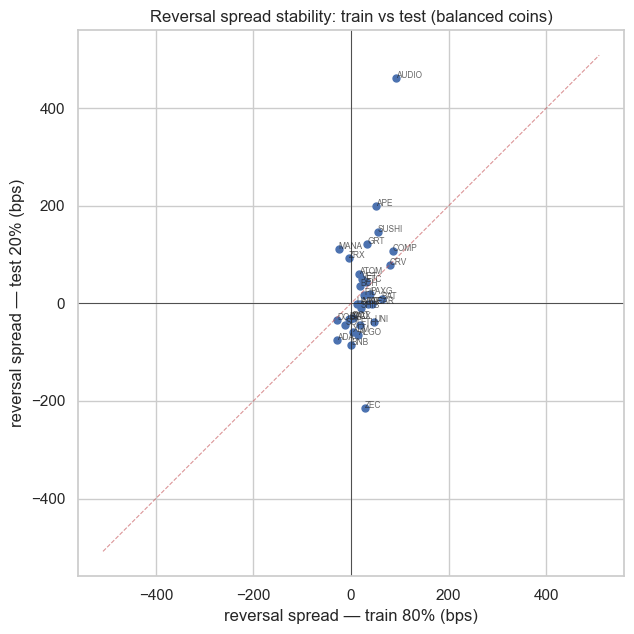

,spread_train_bps,spread_test_bps,sign_match
AUDIO,91.3000,462.1000,True
COMP,86.1000,106.9000,True
CRV,79.9000,79.0000,True
BAT,62.4000,9.0000,True
SUSHI,55.2000,145.2000,True
APE,51.3000,198.5000,True
UNI,46.7000,-39.3000,False
NEAR,41.9000,-2.1000,False
PAXG,38.7000,18.6000,True
LTC,34.5000,-1.7000,False


In [15]:
# --- Filter 2: does the reversal hold out-of-sample? same aggregation on first 80% vs last 20% ---
split_ix = int(len(logret) * 0.80)                    # same boundary as the set-aside 80/20 split
idx_tr, idx_te = logret.index[:split_ix], logret.index[split_ix:]

def rev_spread(sym, idx):
    """mean(after-down) - mean(after-up) in bps, computed on the rows in `idx` only."""
    r = logret.loc[idx, sym]
    lag_dir = r.shift(1).map(lambda x: 1 if x > 0 else -1)
    d = pd.DataFrame({'r': r, 'lag_dir': lag_dir}).dropna()
    up, dn = d.loc[d.lag_dir == 1, 'r'], d.loc[d.lag_dir == -1, 'r']
    return (dn.mean() - up.mean()) * 1e4

stab = pd.DataFrame({
    'spread_train_bps': {s[:-4]: rev_spread(s, idx_tr) for s in balanced_syms},
    'spread_test_bps':  {s[:-4]: rev_spread(s, idx_te) for s in balanced_syms},
})
stab['sign_match'] = np.sign(stab.spread_train_bps) == np.sign(stab.spread_test_bps)
stab = stab.sort_values('spread_train_bps', ascending=False)

print(f'train {idx_tr.min().date()} -> {idx_tr.max().date()} | '
      f'test {idx_te.min().date()} -> {idx_te.max().date()}')
print(f'sign-match (same direction both halves): {stab.sign_match.sum()}/{len(stab)}')
print(f'cross-coin corr(train, test): {stab.spread_train_bps.corr(stab.spread_test_bps):.2f}')
print(f'reversal-positive in BOTH halves: '
      f'{((stab.spread_train_bps > 0) & (stab.spread_test_bps > 0)).sum()}/{len(stab)}\n')

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
lim = max(stab.spread_train_bps.abs().max(), stab.spread_test_bps.abs().max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.8, alpha=0.6)   # y=x = perfect stability
ax.scatter(stab.spread_train_bps, stab.spread_test_bps, s=25)
for t, row in stab.iterrows():
    ax.annotate(t, (row.spread_train_bps, row.spread_test_bps), fontsize=6, alpha=0.7)
ax.set_xlabel('reversal spread — train 80% (bps)')
ax.set_ylabel('reversal spread — test 20% (bps)')
ax.set_title('Reversal spread stability: train vs test (balanced coins)')
fig.tight_layout(); plt.show()

display(stab.round(1))

## Cross-sectional reversal portfolio (rank → demean → normalize)

HW8-style dollar-neutral book on the 32 balanced coins. Each day the signal is **yesterday's return**;
we rank coins cross-sectionally, **demean** the ranks (so the book is dollar-neutral), flip the sign
(**reversal**: long yesterday's relative *losers*, short its *winners*), and **normalize** to gross
exposure 1. Because we demean across the cross-section, the mild common negative drift cancels — we
only bet on *relative* reversion.

Signal uses `shift(1)`, so today's weights depend only on past returns (no lookahead). We evaluate
**gross** and net of two cost assumptions (7 bps limit / 20 bps market all-in), and report metrics on
**full / train / test** windows separately using the metric helpers (`ANN_DAILY = 365`).

In [16]:
# --- Cross-sectional reversal: long yesterday's relative losers, short its winners (HW8 weights) ---
ANN_DAILY = 365
universe = balanced_syms                          # 32 balanced coins from Filter 1
R = logret[universe]

sig  = R.shift(1)                                  # yesterday's return: known at start of day t (no lookahead)
rank = sig.rank(axis=1)                            # cross-sectional rank across coins, each day
w    = -(rank.sub(rank.mean(axis=1), axis=0))      # reversal: short winners (high rank), long losers (low rank)
w    = w.div(w.abs().sum(axis=1), axis=0)          # dollar-neutral (sum w = 0), gross 1 (sum |w| = 1)

gross = (w * R).sum(axis=1).dropna()               # daily portfolio return, before costs
w, R  = w.loc[gross.index], R.loc[gross.index]
tno   = turnover(w)                                # sum |w_t - w_{t-1}| per day
net7  = gross - tno * bps(7.0)                      # limit-order commission (7 bps)
net20 = gross - tno * bps(20.0)                     # market all-in (20 bps)

print(f'universe = {len(universe)} coins | avg daily turnover = {tno.mean():.2f} | '
      f'gross Sharpe = {sharpe(gross, ANN_DAILY):.2f} | '
      f'net7 Sharpe = {sharpe(net7, ANN_DAILY):.2f} | net20 Sharpe = {sharpe(net20, ANN_DAILY):.2f}')

universe = 32 coins | avg daily turnover = 1.38 | gross Sharpe = 5.10 | net7 Sharpe = 3.22 | net20 Sharpe = -0.26


In [17]:
# --- Metrics: full / train / test, for gross and both cost assumptions ---
mkt = R.mean(axis=1)     # equal-weight universe benchmark (for beta)

def window_summary(ret, tag):
    ret = ret.dropna(); idx = ret.index
    return performance_summary(ret, w.loc[idx], mkt.loc[idx], ANN_DAILY, tag)

rows = []
for name, ret in [('gross', gross), ('net_7bps', net7), ('net_20bps', net20)]:
    rows.append(window_summary(ret,                                    f'{name}_full'))
    rows.append(window_summary(ret.loc[ret.index.intersection(idx_tr)], f'{name}_train'))
    rows.append(window_summary(ret.loc[ret.index.intersection(idx_te)], f'{name}_test'))
perf = pd.DataFrame(rows)
display(perf.round(3))

,ann_return,ann_vol,sharpe,avg_turnover,max_drawdown,max_dd_dur_bars,beta
gross_full,0.9590,0.1880,5.0950,1.3810,-0.1020,146.0000,0.0250
gross_train,0.6910,0.1730,3.9830,1.3760,-0.1020,146.0000,0.0240
gross_test,2.0290,0.2300,8.8170,1.4030,-0.0880,19.0000,0.0340
net_7bps_full,0.6060,0.1880,3.2180,1.3810,-0.1970,538.0000,0.0250
net_7bps_train,0.3390,0.1740,1.9550,1.3760,-0.1970,538.0000,0.0240
net_7bps_test,1.6700,0.2300,7.2520,1.4030,-0.0910,26.0000,0.0350
net_20bps_full,-0.0490,0.1890,-0.2620,1.3810,-0.7960,"1,698.0000",0.0250
net_20bps_train,-0.3140,0.1740,-1.8030,1.3760,-0.7960,"1,357.0000",0.0240
net_20bps_test,1.0040,0.2310,4.3510,1.4030,-0.0970,42.0000,0.0350


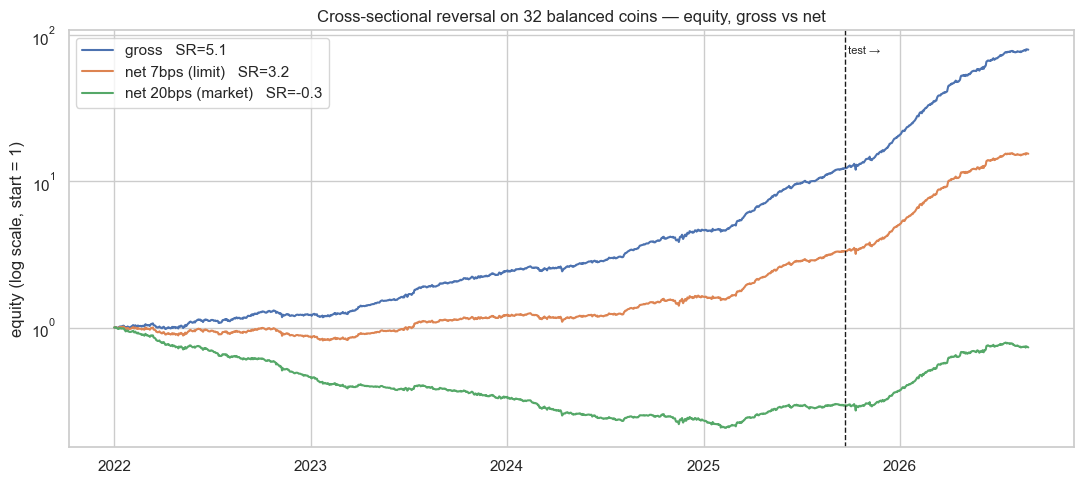

In [18]:
# --- Equity curves (log scale) with the train/test boundary marked ---
fig, ax = plt.subplots(figsize=(11, 5))
for series, lab in [(gross, 'gross'), (net7, 'net 7bps (limit)'), (net20, 'net 20bps (market)')]:
    e = equity_curve(series)
    ax.plot(e.index, e, label=f'{lab}   SR={sharpe(series, ANN_DAILY):.1f}')
ax.axvline(idx_te[0], color='k', ls='--', lw=1)
ax.text(idx_te[0], ax.get_ylim()[1], ' test →', va='top', fontsize=8)
ax.set_yscale('log'); ax.set_ylabel('equity (log scale, start = 1)')
ax.legend(loc='upper left')
ax.set_title('Cross-sectional reversal on 32 balanced coins — equity, gross vs net')
fig.tight_layout(); plt.show()

In [19]:
# --- Chronological 80/20 train/test split (time series: no shuffling) ---
# Select cointegrated pairs on the 80% TRAIN; validate/trade on the held-out 20% TEST.
split_ix = int(len(logpx) * 0.80)
split_date = logpx.index[split_ix]
logpx_train, logpx_test = logpx.iloc[:split_ix], logpx.iloc[split_ix:]
print(f'split at {split_date.date()}')
print(f'train (80%): {logpx_train.shape}  {logpx_train.index.min().date()} -> {logpx_train.index.max().date()}')
print(f'test  (20%): {logpx_test.shape}  {logpx_test.index.min().date()} -> {logpx_test.index.max().date()}')

split at 2025-09-22
train (80%): (1360, 60)  2022-01-01 -> 2025-09-21
test  (20%): (341, 60)  2025-09-22 -> 2026-08-28
